In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
crash_df = sns.load_dataset('car_crashes')
crash_df

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_69357/3234414368.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(crash_df['not_distracted'], kde=False, bins=25)


<Axes: xlabel='not_distracted'>

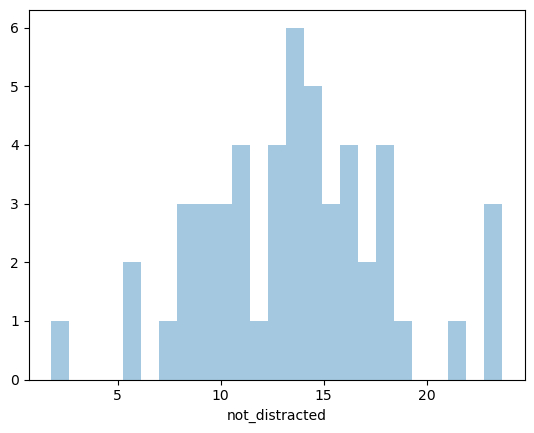

In [9]:
# Distribution plot
sns.distplot(crash_df['not_distracted'], kde=False, bins=25)

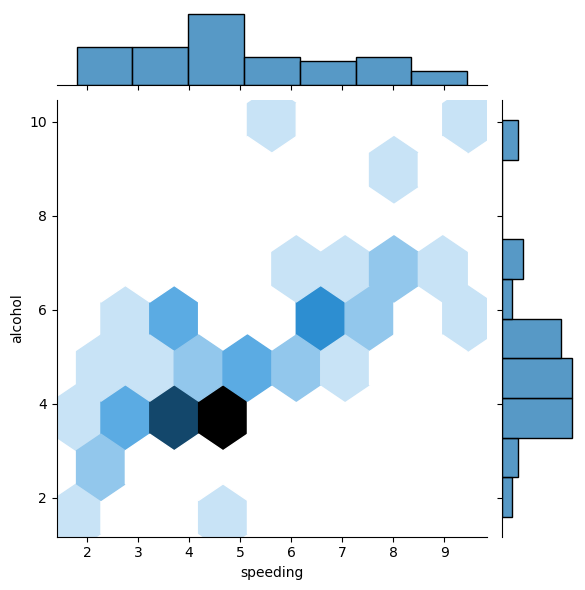

In [12]:
# Joint plot
sns.jointplot(x='speeding',y='alcohol',data=crash_df,kind='hex')

<Axes: xlabel='alcohol', ylabel='Density'>

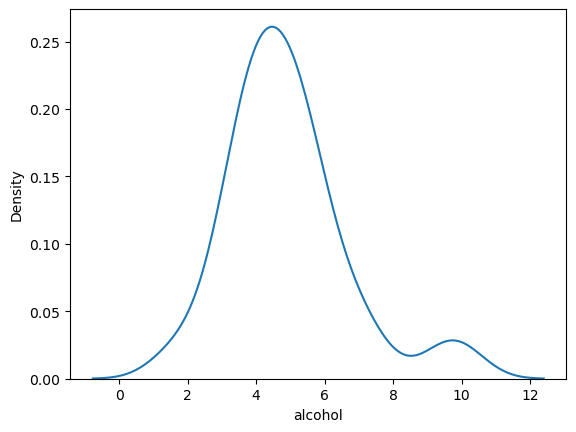

In [13]:
# KDE plot
sns.kdeplot(crash_df['alcohol'])

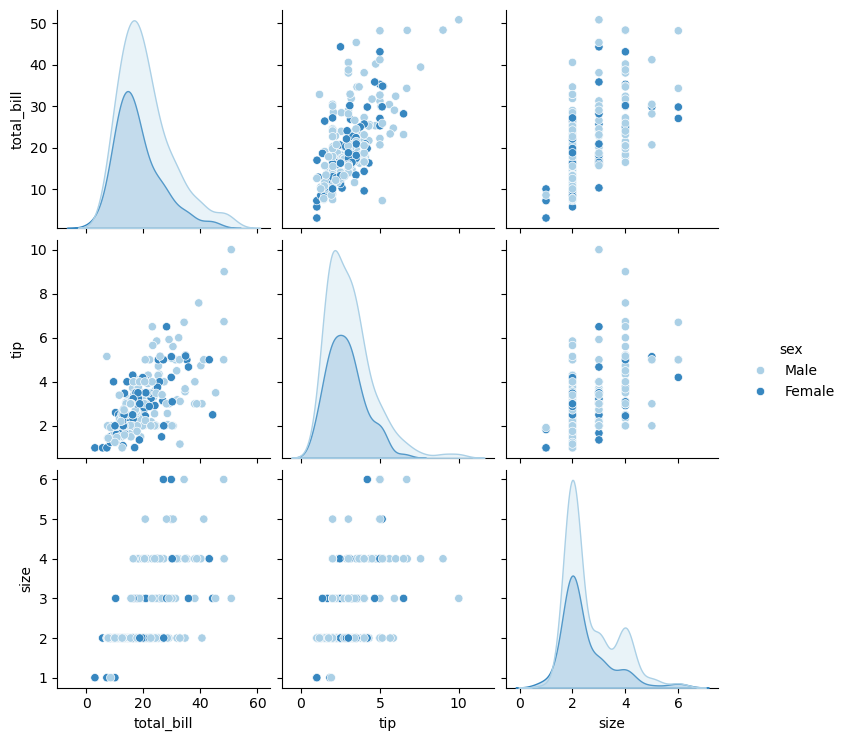

In [23]:
# Pair plot

# sns.pairplot(crash_df)

tips_df = sns.load_dataset('tips')
sns.pairplot(tips_df, hue='sex', palette='Blues')

<Axes: xlabel='tip'>

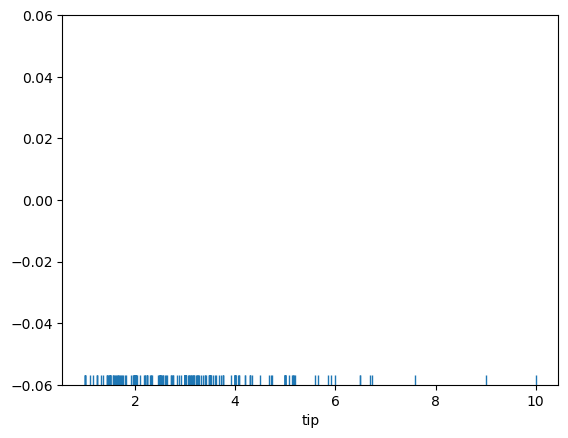

In [24]:
# Rug plot

sns.rugplot(tips_df['tip'])

<Figure size 800x400 with 0 Axes>

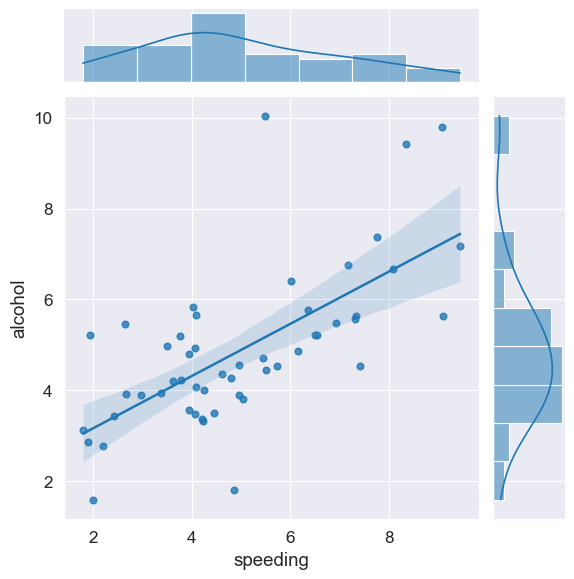

In [51]:
# Style

sns.set_style('darkgrid')

plt.figure(figsize=(8,4))

sns.set_context('paper', font_scale=1.4)

sns.jointplot(x='speeding',y='alcohol',data=crash_df,kind='reg')

# Getting rid of the lines around
# sns.despine(left=True, bottom=True, right=True)

<Axes: xlabel='sex', ylabel='total_bill'>

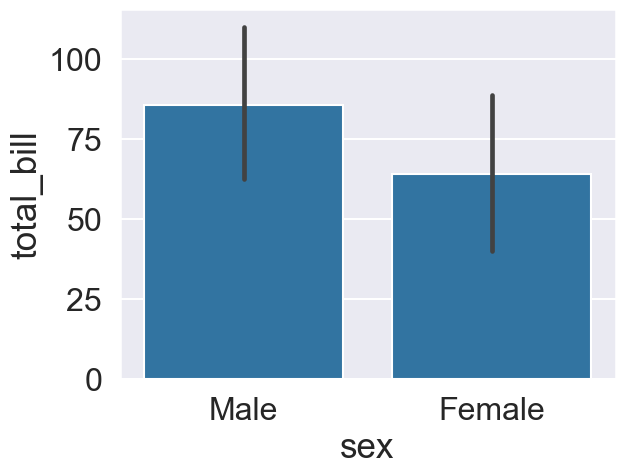

In [44]:
# Categorical Plots
# Bar plot

sns.barplot(data=tips_df, x='sex',y='total_bill', estimator=np.cov)

<Axes: xlabel='sex', ylabel='count'>

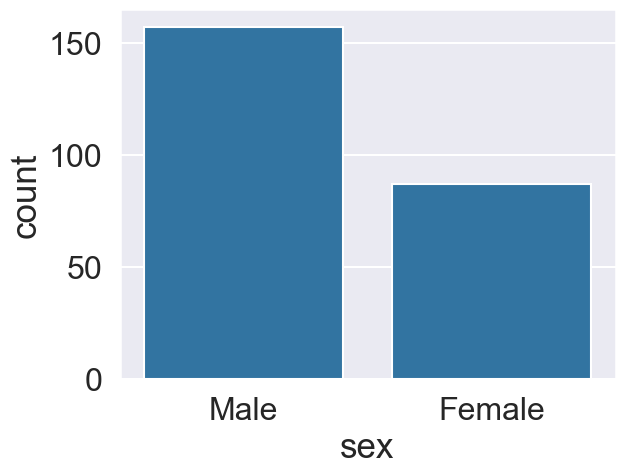

In [45]:
# Count plot
sns.countplot(x='sex',data=tips_df)

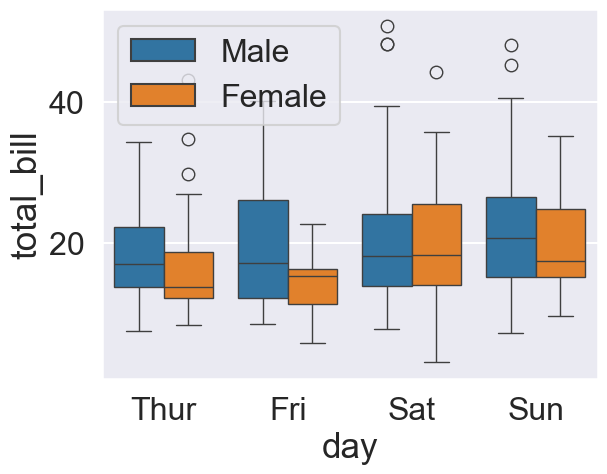

In [47]:
# Box plot

sns.boxplot(x='day', y='total_bill', data=tips_df, hue='sex')
plt.legend(loc=0)

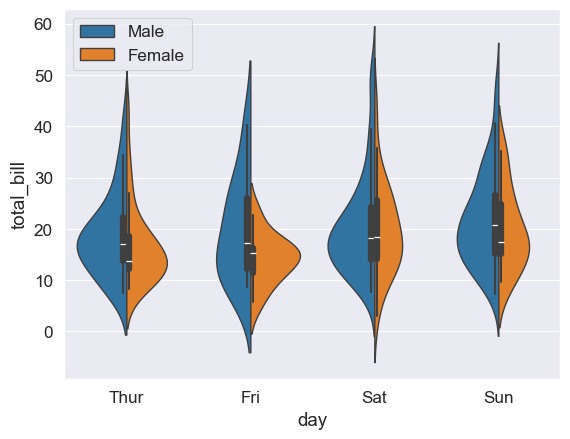

In [52]:
# Violin plot

sns.violinplot(x='day',y='total_bill',hue='sex',data=tips_df, split=True)
plt.legend(loc=0)

<Axes: xlabel='day', ylabel='total_bill'>

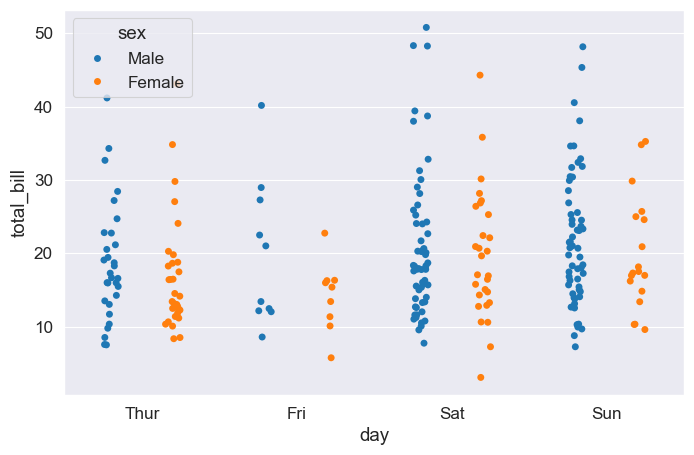

In [57]:
# Strip plot
plt.figure(figsize=(8,5))
sns.stripplot(x='day',y='total_bill',data=tips_df, jitter=True, hue='sex', dodge=True)

<Axes: xlabel='day', ylabel='total_bill'>

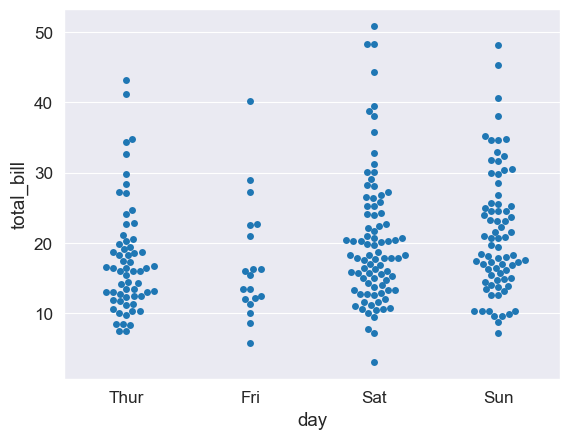

In [61]:
# Swarm plot


sns.swarmplot(x='day',y='total_bill',data=tips_df)

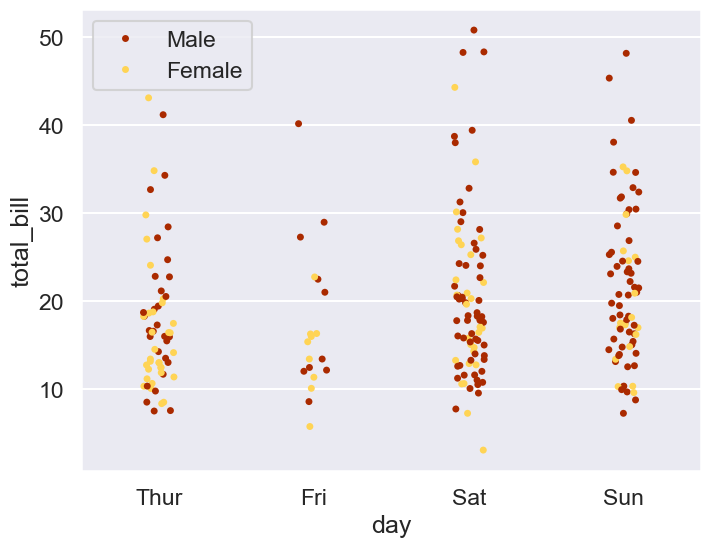

In [69]:
# Palettes

plt.figure(figsize=(8,6))
sns.set_style('darkgrid')
sns.set_context('talk')
sns.stripplot(x='day',y='total_bill', data=tips_df, hue='sex', palette='afmhot')
plt.legend(loc=0)

<Axes: >

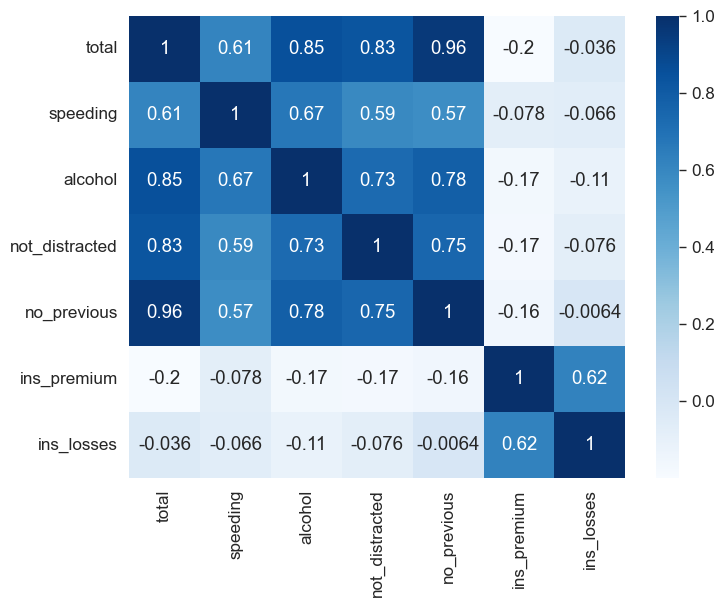

In [77]:
# Matrix plots
# Heatmaps
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

crash_mx = crash_df.select_dtypes(include='number').corr()

sns.heatmap(crash_mx, annot=True, cmap='Blues')

/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_69357/2917746279.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights = flights.pivot_table(index='month',columns='year',values='passengers')


<Axes: xlabel='year', ylabel='month'>

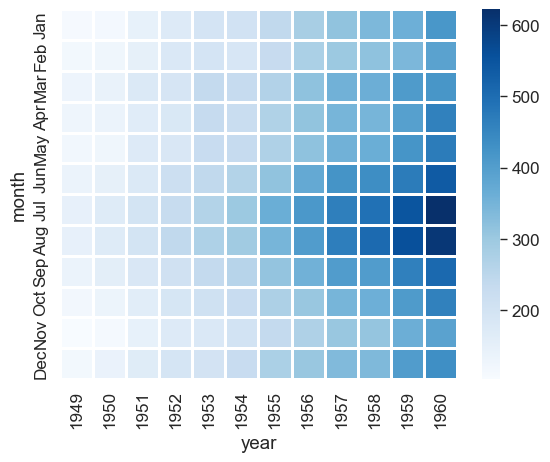

In [82]:
flights = sns.load_dataset('flights')
flights = flights.pivot_table(index='month',columns='year',values='passengers')
sns.heatmap(flights, cmap='Blues', linecolor='white', linewidth=1)

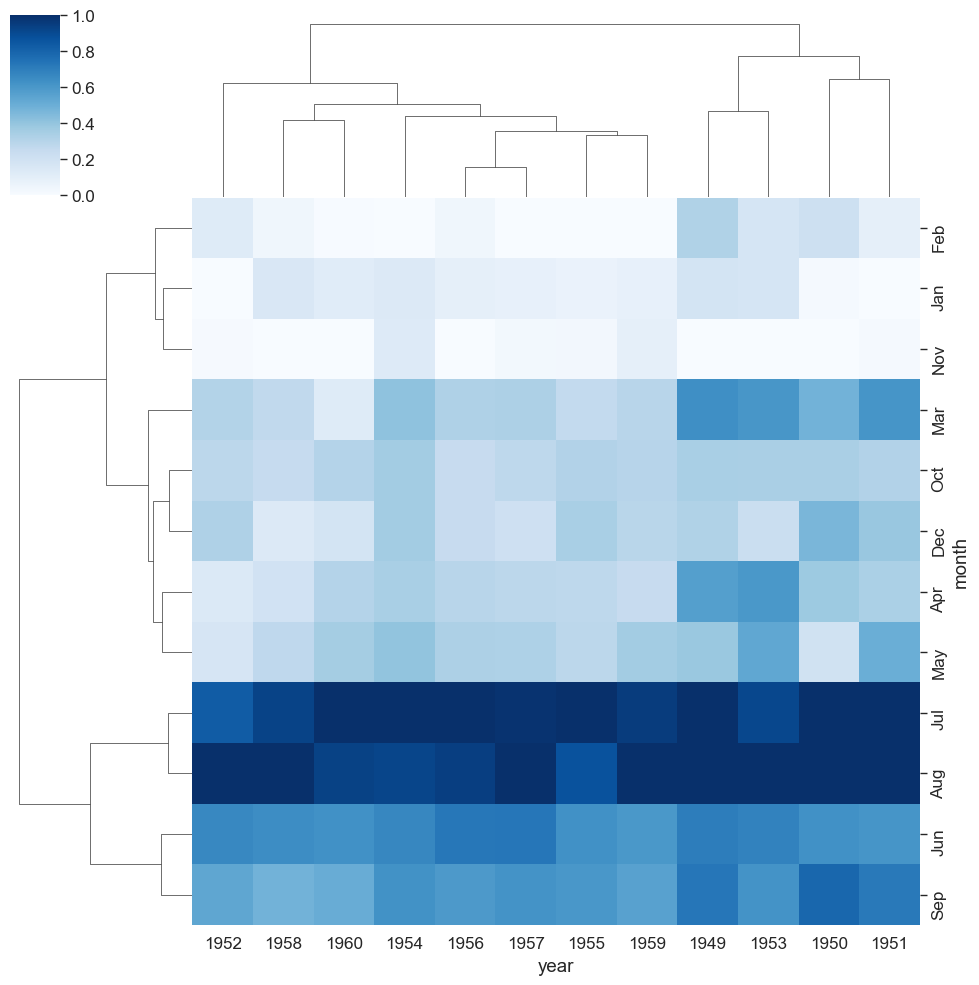

In [89]:
# Cluster Map


iris=sns.load_dataset('iris')
'''
species = iris.pop('species')
sns.clustermap(iris)
'''

sns.clustermap(flights, cmap='Blues', standard_scale=1)

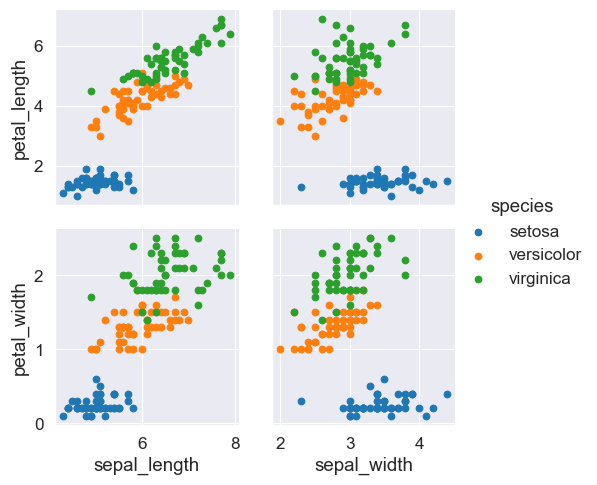

In [100]:
# PairGrid
# iris_g = sns.PairGrid(iris, hue='species')
# iris_g.map(plt.scatter)
# iris_g.map_diag(plt.hist)
# iris_g.map_offdiag(plt.scatter)
#iris_g.map_upper(plt.scatter)
# iris_g.map_lower(sns.kdeplot)
iris_g = sns.PairGrid(iris, hue='species',x_vars=['sepal_length', 'sepal_width'],
                     y_vars=['petal_length', 'petal_width'])
iris_g.map(plt.scatter)
iris_g.add_legend()

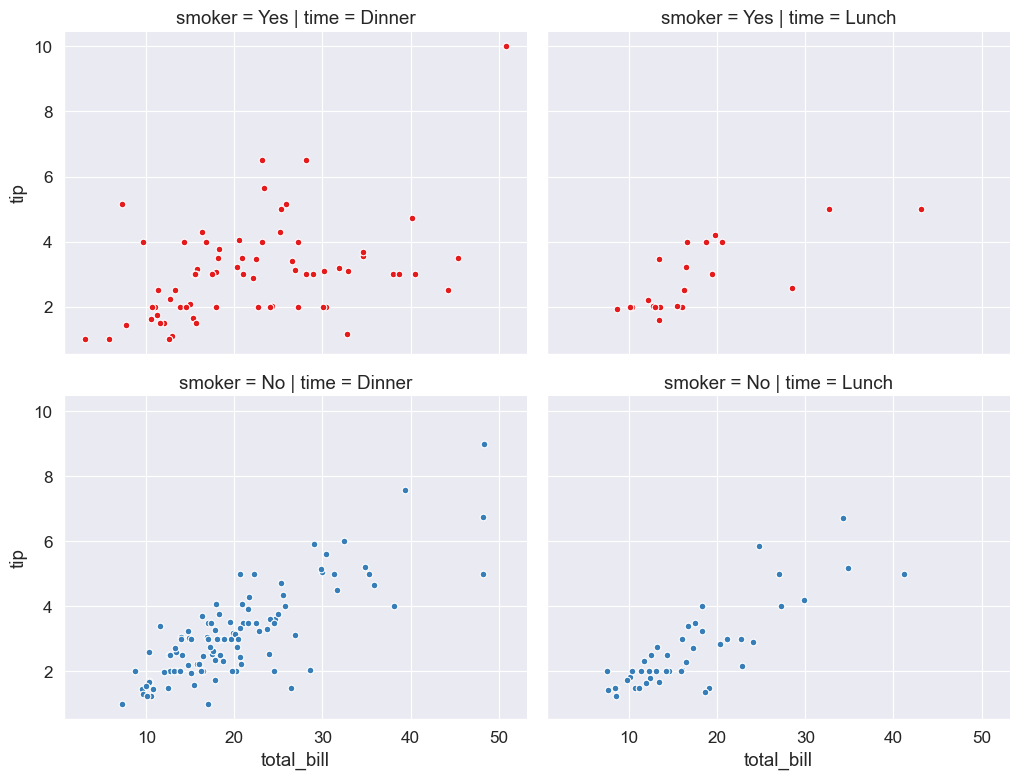

In [113]:
# Facet Grid
tips_fg = sns.FacetGrid(tips_df, col='time', row='smoker', hue='smoker',height=4,aspect=1.3, col_order=['Dinner', 'Lunch'],
                       palette='Set1')
# tips_fg.map(plt.hist, 'total_bill', bins=8)
tips_fg.map(plt.scatter, 'total_bill', 'tip', edgecolor='w')

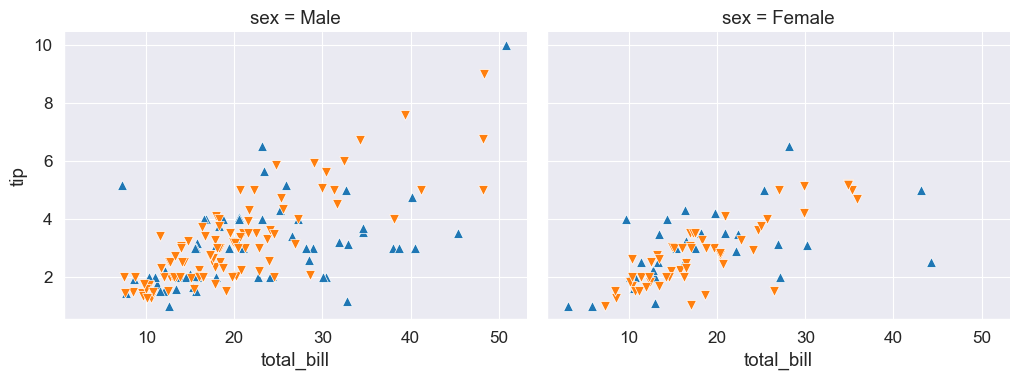

In [116]:
kws = dict(s=50, linewidth=.5, edgecolor='white')
tips_fg = sns.FacetGrid(tips_df, col='sex', hue='smoker', height=4, aspect=1.3,
                       hue_order=['Yes','No'],
                       hue_kws=dict(marker=['^', 'v']))
tips_fg.map(plt.scatter, 'total_bill', 'tip', **kws)

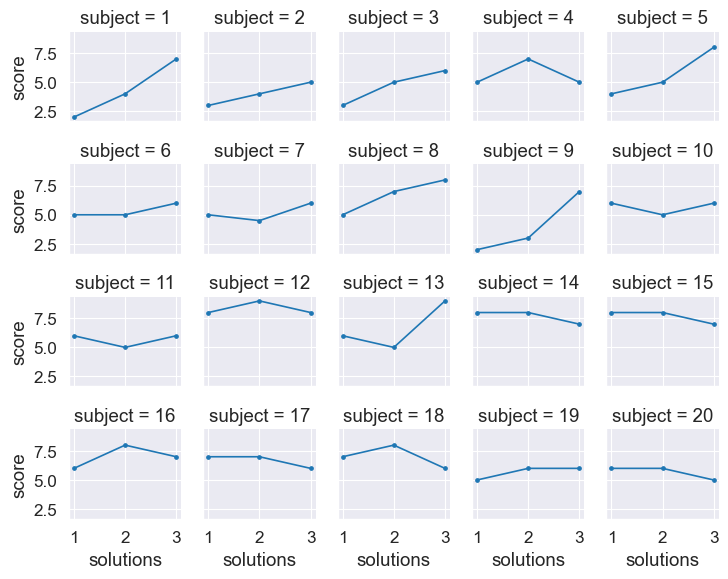

In [120]:
att_df = sns.load_dataset('attention')
att_fg = sns.FacetGrid(att_df,col='subject', col_wrap=5, height=1.5)
att_fg.map(plt.plot, 'solutions', 'score', marker='.')

In [121]:
# Regression Plot

tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Text(0.5, 1.0, 'Tip vs Total Bill by Sex')

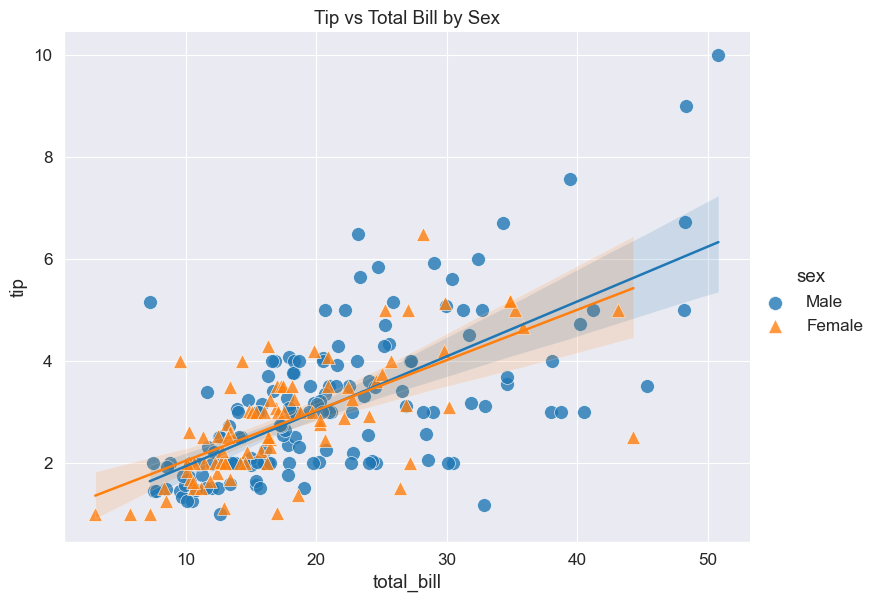

In [126]:
sns.set_context('paper', font_scale=1.4)

sns.lmplot(
    x='total_bill', 
    y='tip', 
    hue='sex', 
    data=tips_df, 
    markers=['o', '^'],
    scatter_kws={'s': 100, 'linewidths': 0.5, 'edgecolor': 'w'},
    height=6, aspect=1.3
)

plt.title('Tip vs Total Bill by Sex')

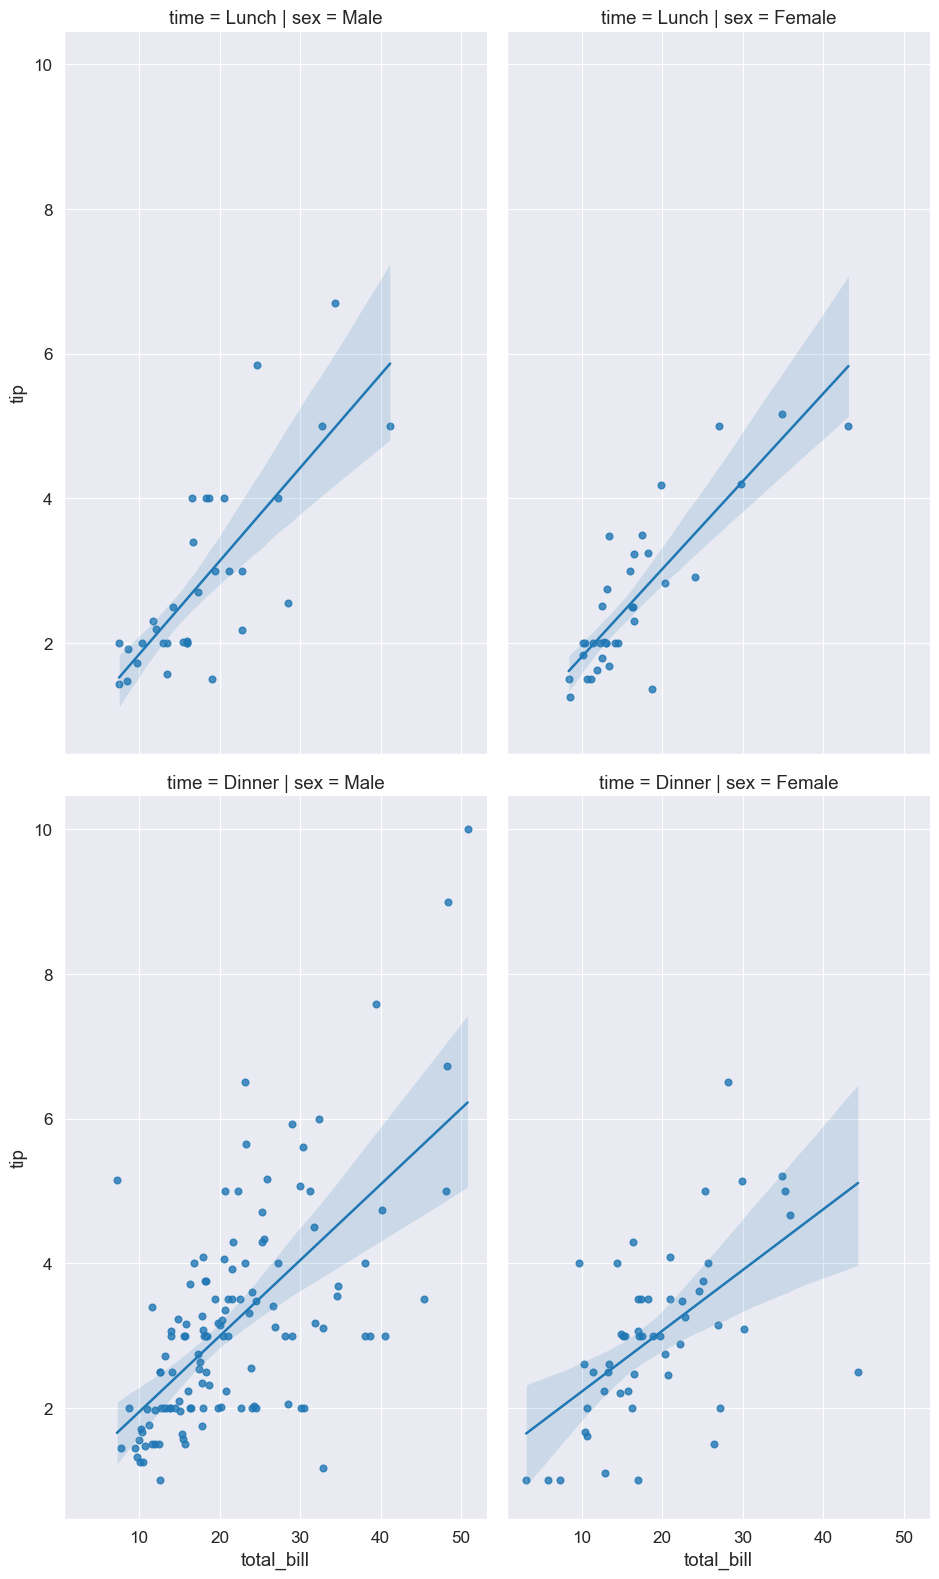

In [128]:
sns.set_context('paper', font_scale=1.4)
sns.lmplot(
    x='total_bill',
    y='tip',
    col='sex',
    row='time',
    data=tips_df,
    height=8,
    aspect=0.6
)